In [3]:
# Mount Drive e setup cartelle
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Progetto_EVWSD_ML"
IMAGES_DIR = os.path.join(DRIVE_PROJECT_PATH, "data/images")
HF_CACHE_DIR = os.path.join(DRIVE_PROJECT_PATH, "data/hf_cache")
IMAGES_ROOT  = os.path.join(IMAGES_DIR, "imgs")

os.makedirs(HF_CACHE_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q sentence-transformers datasets pillow torch

In [5]:
from datasets import load_dataset
from huggingface_hub import hf_hub_download
import zipfile

dataset = load_dataset("swap-uniba/EVWSD-ITA", cache_dir=HF_CACHE_DIR)

# scarica immagini solo se non già presenti
if not os.path.exists(IMAGES_ROOT):
    zip_path = hf_hub_download(
        repo_id="swap-uniba/EVWSD-ITA",
        filename="imgs.zip",
        repo_type="dataset",
        cache_dir=HF_CACHE_DIR
    )
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(IMAGES_DIR)
    print("Immagini estratte.")
else:
    print("Immagini già presenti.")

Immagini già presenti.


In [6]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# vision encoder: CLIP base (stesso backbone del modello multilingue)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("Modello CLIP caricato.")

Device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Modello CLIP caricato.


In [15]:
import random
from PIL import Image

IMG_EXT = ".png"
N_CANDIDATE = 10

def load_image(img_path_str):
    full_path = os.path.join(IMAGES_ROOT, img_path_str + IMG_EXT)
    if not os.path.exists(full_path):
        return None
    return Image.open(full_path).convert("RGB")

def encode_images(pil_images, model, processor, device):
    inputs = processor(images=pil_images, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        vision_out = model.vision_model(pixel_values=inputs["pixel_values"])
        emb = model.visual_projection(vision_out.pooler_output)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu()

def scegli_pacchetto_casuale(dataset, n=N_CANDIDATE):
    idx = random.randint(0, len(dataset["train"]) - 1)
    row = dataset["train"][idx]

    # 1. prendi co-iponimi (più simili)
    # 2. poi stesso lemma senso diverso
    # 3. se non bastano, riempi con immagini casuali da altre istanze
    candidati = {}  # path → img, mantiene unicità

    for path, is_co in zip(row["images"], row["is_co_hyp"]):
        if path not in candidati:
            img = load_image(path)
            if img is not None:
                candidati[path] = (img, "co_hyp" if is_co else "same_lemma")

    # se non bastano riempi con immagini casuali da altre istanze
    tentativi = 0
    while len(candidati) < n and tentativi < 1000:
        tentativi += 1
        row_rand = dataset["train"][random.randint(0, len(dataset["train"]) - 1)]
        for path in row_rand["images"]:
            if path not in candidati and len(candidati) < n:
                img = load_image(path)
                if img is not None:
                    candidati[path] = (img, "random")

    # se ci sono più di n, priorità: co_hyp > same_lemma > random
    if len(candidati) > n:
        co_hyp_paths   = [p for p, (_, t) in candidati.items() if t == "co_hyp"]
        same_lem_paths = [p for p, (_, t) in candidati.items() if t == "same_lemma"]

        paths = co_hyp_paths + same_lem_paths
        if len(paths) < n:
            random_paths = [p for p, (_, t) in candidati.items() if t == "random"]
            paths += random.sample(random_paths, n - len(paths))
        elif len(paths) > n:
            paths = paths[:n]
    else:
        paths = list(candidati.keys())

    random.shuffle(paths)
    immagini = [candidati[p][0] for p in paths]
    tipi     = [candidati[p][1] for p in paths]

    embeddings_candidati = encode_images(immagini, clip_model, clip_processor, device)

    metadati = {
        "id":           row["id"],
        "lemma":        row["lemma"],
        "gloss":        row["gloss"],
        "n_co_hyp":     tipi.count("co_hyp"),
        "n_same_lemma": tipi.count("same_lemma"),
        "n_random":     tipi.count("random"),
        "n_candidate":  len(immagini),
    }

    return immagini, embeddings_candidati, metadati

Istanza:         bn:00056206n
Lemma:           barena
Gloss:           In sedimentologia, si definisce piana di marea o piana tidale un ambiente sedimentario in cui la sedimentazione è controllata dal flusso e riflusso della marea: si sviluppano lungo coste basse, a debole inclinazione, con elevata escursione di marea, nelle quali quindi l'innalzamento e l'abbassamento del livello marino comporta sommersione ed esposizione ciclica di ampie estensioni di territorio.
Co-iponimi:      10
Stesso lemma:    0
Casuali:         0
Totale:          10
Shape embeddings: torch.Size([10, 512])


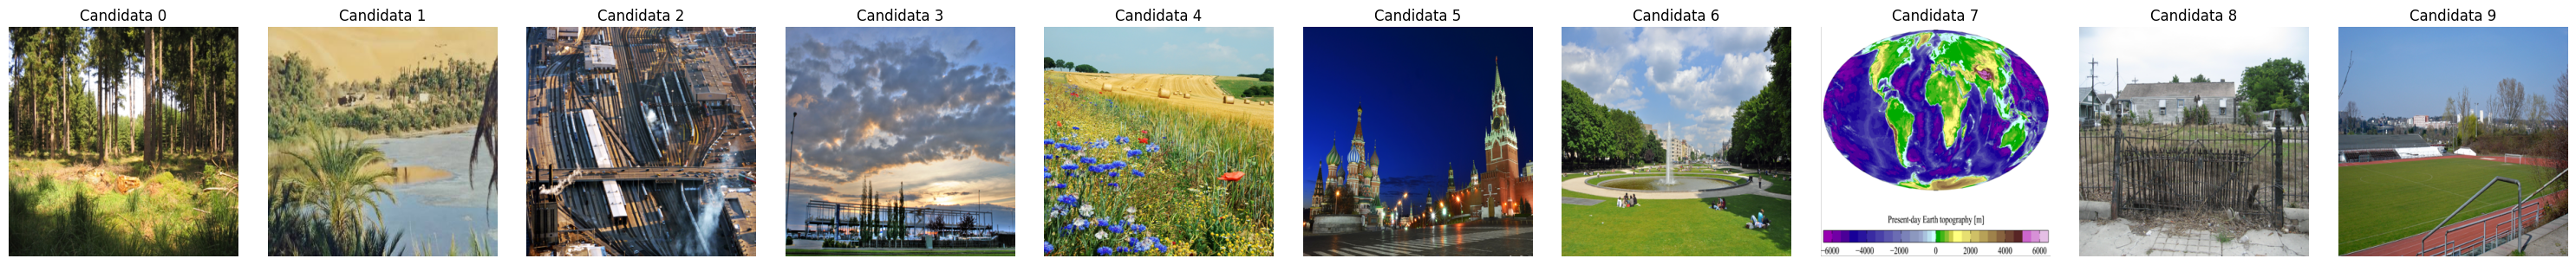

In [18]:
import matplotlib.pyplot as plt

immagini, embeddings_candidati, metadati = scegli_pacchetto_casuale(dataset)

print(f"Istanza:         {metadati['id']}")
print(f"Lemma:           {metadati['lemma']}")
print(f"Gloss:           {metadati['gloss']}")
print(f"Co-iponimi:      {metadati['n_co_hyp']}")
print(f"Stesso lemma:    {metadati['n_same_lemma']}")
print(f"Casuali:         {metadati['n_random']}")
print(f"Totale:          {metadati['n_candidate']}")
print(f"Shape embeddings: {embeddings_candidati.shape}")

fig, axes = plt.subplots(1, len(immagini), figsize=(3 * len(immagini), 3))
for i, (ax, img) in enumerate(zip(axes, immagini)):
    ax.imshow(img)
    ax.set_title(f"Candidata {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()
